# EDA - Exploratory Data Analysis - Salary survey

### Index:
1) **Importing libraries:** pandas, numpy, seaborn, sklearn, etc.
2) **Importing data:** Importing data set and displaying first and last 5 rows.
3) **Data cleaning:** Checking shape, replacing values, removing unnecessary columns and rows that could affect the analysis, removing outliers, dropping null values, etc.
4) **Setting question and answer them:** In this section i set main question which i answered using plots.
5) **Machine learning preparation:** Transforming categorical data into numerical (encoding)

# 1) Importing the libraries to start working with the CSV file

In [1]:
import pandas as pd # Pandas library
import numpy as np # Numpy library
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline
sns.set(color_codes=True) # SNS colors
import sklearn.preprocessing as preproc # Enconding - Transforming categorical data into numerical
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2 

----

# 2) Importing the data, making a copy of the raw data and displaying the first and last 5 rows

In [2]:
raw_data = pd.read_csv("Salary_Survey.csv") # Importing the dataset
df = raw_data.copy() # Making a copy of the raw data
df.head() # Displaying the first 5 rows

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",...,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,...,5-7 years,5-7 years,Master's degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Non-binary,NaN,NaN,NaN,NaN,NaN,NaN
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,...,2 - 4 years,2 - 4 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,...,8 - 10 years,5-7 years,College degree,Woman,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.tail() # Displaying the last 5 rows

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",...,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
28173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


-----

# 3) Data Cleaning

## 3.1) Checking the shape of the Data Frame

In [4]:
print(df.shape) # Checking the shape of the data frame
print(f"\nThe data frame contains a total number of {df.shape[0]} rows and {df.shape[1]} columns") # Printing the results above

(28178, 23)

The data frame contains a total number of 28178 rows and 23 columns


## 3.2) Checkin Data types

In [5]:
df.dtypes # Checking data type for each column

Timestamp                                                                                                                                                                                                                                   str
How old are you?                                                                                                                                                                                                                            str
What industry do you work in?                                                                                                                                                                                                               str
Job title                                                                                                                                                                                                                                   str
If your job title needs additional conte

**Important** - As we can see in the result above, the names of the columns are not suitable for data management. Let's change them.

In [6]:
df.columns

Index(['Timestamp', 'How old are you?', 'What industry do you work in?',
       'Job title',
       'If your job title needs additional context, please clarify here:',
       'What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)',
       'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.',
       'Please indicate the currency',
       'If "Other," please indicate the currency here: ',
       'If your income needs additional context, please provide it here:',
       'What country do you work in?',
       'If you're in the U.S., what state do you work in?',
       'What city do you work in?',
       'How many years of professional work experience do you have overall?',
       

In [7]:
df = df.rename(columns={
    df.columns[1]:'Age',
    df.columns[2]:'Industry',
    df.columns[3]:'Job_title',
    df.columns[4]:"Job_context",
    df.columns[5]:"Annual_salary",
    df.columns[6]:"Bonuses",
    df.columns[7]:"Currency",
    df.columns[8]:"Other_currencies",
    df.columns[9]:"Income_context",
    df.columns[10]:"Country_of_work",
    df.columns[11]:"US-State_of_work",
    df.columns[12]:"City_of_work",
    df.columns[13]:"YoE",
    df.columns[14]:"YoE_field",
    df.columns[15]:"Education_Level",
    df.columns[15]:"Education_Level",
    df.columns[16]:"Gender",
    df.columns[13]:"YoE"})

df.columns

Index(['Timestamp', 'Age', 'Industry', 'Job_title', 'Job_context',
       'Annual_salary', 'Bonuses', 'Currency', 'Other_currencies',
       'Income_context', 'Country_of_work', 'US-State_of_work', 'City_of_work',
       'YoE', 'YoE_field', 'Education_Level', 'Gender', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22'],
      dtype='str')

## 3.3) Checking data types

In [8]:
df.dtypes

Timestamp               str
Age                     str
Industry                str
Job_title               str
Job_context             str
Annual_salary           str
Bonuses             float64
Currency                str
Other_currencies        str
Income_context          str
Country_of_work         str
US-State_of_work        str
City_of_work            str
YoE                     str
YoE_field               str
Education_Level         str
Gender                  str
Unnamed: 17         float64
Unnamed: 18         float64
Unnamed: 19         float64
Unnamed: 20         float64
Unnamed: 21         float64
Unnamed: 22         float64
dtype: object

## 3.4) Checking for null values

In [9]:
df_null = df.isnull().sum() # Summing the total number of null values
df_null = round(df_null / len(df),2) # Getting the null relative frequency for each column
df_null.sort_values(ascending=False) # Sorting the values from the highest to the lowest.

Unnamed: 22         1.00
Unnamed: 18         1.00
Unnamed: 17         1.00
Unnamed: 21         1.00
Unnamed: 19         1.00
Unnamed: 20         1.00
Other_currencies    0.99
Income_context      0.89
Job_context         0.74
Bonuses             0.26
US-State_of_work    0.18
Industry            0.01
City_of_work        0.01
Education_Level     0.01
Gender              0.01
Annual_salary       0.00
Job_title           0.00
Timestamp           0.00
Age                 0.00
YoE_field           0.00
YoE                 0.00
Currency            0.00
Country_of_work     0.00
dtype: float64

**Important** - As we can see in the result above, the columns which contain the highest number of null values are: 

1) Job_context = Nearly 80% of the values within this column are null
2) Other_currencies = almost 100% of the values within this column are null
3) Income_context = Nearly 90% of the values within this column are null
4) All the "Unnamed" columns are completely fill with null values

By acknowledging this, we can delete them from the data frame

**Important** - Timestamp dose not have null values, but I do not find it relevant. I will drop it as well.


## 3.5) Dropping unnecessary columns

In [10]:
# Dropping unnecessary columns such TimeStamp and columns with a higher number of null values.
df.drop(columns=['Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20','Unnamed: 21', 'Unnamed: 22', "Job_context","Other_currencies","Income_context","Timestamp"], inplace=True)
df.head() # Displaying the first 5 rows

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,25-34,Computing or Tech,Change & Internal Communications Manager,"54,600",4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman


## 3.6) Dropping duplicates and reseting index

In [11]:
print(df.shape) # Checking the shape of the dataframe again
print(f"\nThe data frame contains a total number of {df.shape[0]} rows and {df.shape[1]} columns") # Printing the results

(28178, 13)

The data frame contains a total number of 28178 rows and 13 columns


In [12]:
# Dropping duplicates
df.drop_duplicates(inplace=True)
# Reseting index
df.reset_index(drop=True, inplace=True)

In [13]:
df_null = df.isnull().sum()
df_null # Checking the total number of null values

Age                    1
Industry              75
Job_title              2
Annual_salary          1
Bonuses             7261
Currency               1
Country_of_work        1
US-State_of_work    5007
City_of_work          83
YoE                    1
YoE_field              1
Education_Level      220
Gender               171
dtype: int64

In [14]:
print(df.shape) # Checking the shape
print(f"\nThe data frame contains a total number of {df.shape[0]} rows and {df.shape[1]} columns") # Printing results

(27932, 13)

The data frame contains a total number of 27932 rows and 13 columns


**Important** - As we can see in the result above, we considerably decreased the number of null values and dropped duplicates.

Before continuing with the EDA process. We will do the next, if the number of null values is higher than 10% of the data. We will replace the null values, otherwise we will drop them.

In [15]:
for i in range(len(df_null)):
    if df_null.iloc[i] / len(df) > 0.10:
        print(f"More than 10% of the data are null values",{df_null.index[i]})
    else:
        print("Ok")

Ok
Ok
Ok
Ok
More than 10% of the data are null values {'Bonuses'}
Ok
Ok
More than 10% of the data are null values {'US-State_of_work'}
Ok
Ok
Ok
Ok
Ok


## 3.7) Data cleaning - String columns

**Important** - The only null values which we will replace are from the column Bonuses and US state of work. 

Now we are going to trim all the columns within the Data Frame to eliminate the blank spaces

In [16]:
columns = df.select_dtypes(include="object").columns

for i in range(len(columns)): # For loop to iterate for each column
    df[columns[i]] = df[columns[i]].str.strip() # Eliminating blank spaces from the values

C:\Users\leona\AppData\Local\Temp\ipykernel_26160\2689118076.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns = df.select_dtypes(include="object").columns


----

**Important** - We will start looking for values within the columns which they might refer to the same. We will do this in order to change the value and be more organized.

### Age column

In [17]:
df["Age"].value_counts()
# We can see that the value which contains the value which contains the highest frequency is the interval "25 - 34"

Age
25-34         12582
35-44          9860
45-54          3176
18-24          1219
55-64           985
65 or over       95
under 18         14
Name: count, dtype: int64

### Industry column

In [18]:
print(f"the total number of unique values in the Industry columns is: {len(df["Industry"].unique())}")

SyntaxError: f-string: unmatched '[' (2560980414.py, line 1)

In [ ]:
df["Industry"].value_counts().head(60).sum() # Total values

26432

**Important** - As we can see in the result above, most of the data are concentrated in the main 60 Industries.

In [ ]:
df_industry = df["Industry"].value_counts().head(60) # Absolute frequency for each value
df_industry = round(df_industry / len(df),2) # Relative frequency
df_industry.sum() # Suming the first 50 rows

0.9200000000000002

**Important** - the main 60 industries by frequency represent 92% of the values in the column **Industry**. By having this under consideration, i decided that the best approach for the analysis will be to remove the rest of the industries and keep the main 60. This step has as goal to avoid analysing typos or single industry which has not weight on the data set.

Documentation, P. (2025) Pandas.dataframe.isin#, pandas.DataFrame.isin - pandas 2.3.3 documentation.Available at: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html (Accessed: 31 October 2025). 



In [ ]:
industry_index = df["Industry"].value_counts().head(60).index # Storing the main 60 industries index into the variable
df = df[df["Industry"].isin(industry_index)] # Filtering the data frame
df.reset_index(drop=True) # Reseting the index

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,25-34,Computing or Tech,Change & Internal Communications Manager,"54,600",4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26427,35-44,Health care,Pharmacy Buyer,53060,0.0,USD,United States of America,Missouri,Springfield,21 - 30 years,11 - 20 years,Some college,Woman
26428,45-54,"Accounting, Banking & Finance",Product Manager Lead,117000,8000.0,USD,USA,Missouri,Remote,11 - 20 years,11 - 20 years,College degree,Woman
26429,45-54,Education (Primary/Secondary),Curriculum Writer,70000,0.0,USD,United States,South Carolina,Bennettsville,21 - 30 years,21 - 30 years,Master's degree,Woman
26430,55-64,Government and Public Administration,Clerical Officer,28600,NaN,EUR,Ireland,NaN,Dublin,21 - 30 years,1 year or less,"Professional degree (MD, JD, etc.)",Man


In [ ]:
print(f"the total number of unique values in the Industry columns is: {len(df["Industry"].unique())}")

the total number of unique values in the Industry columns is: 60


In [ ]:
# Replacing values refering to the same industry
df["Industry"] = df["Industry"].replace({"Pharmaceuticals":"Pharmaceutical", 
                       "Pharma":"Pharmaceutical",
                        "Biotech/Pharma":"Pharmaceutical",
                       "Libraries":"Library",
                        "Oil & Gas":"Oil and Gas"})

In [ ]:
print(f"the total number of unique values in the Industry columns is: {len(df["Industry"].unique())}")

the total number of unique values in the Industry columns is: 55


### Job title

In [ ]:
len(df["Job_title"].unique())
print(f"the total number of unique values in the job title columns is: {len(df["Job_title"].unique())}")
df["Job_title"].value_counts().head(30)
# Since we have different job titles and they could refer to diferent areas (Marketing, sales, HR, etc) I will leave the column as it is.

the total number of unique values in the job title columns is: 12703


Job_title
Software Engineer           302
Project Manager             235
Senior Software Engineer    207
Director                    201
Executive Assistant         179
Teacher                     165
Librarian                   155
Program Manager             151
Manager                     141
Product Manager             127
Administrative Assistant    120
Attorney                    112
Data Analyst                106
Associate                   104
Marketing Manager            95
Engineering Manager          91
Software Developer           91
Analyst                      90
Office Manager               90
Consultant                   87
Paralegal                    86
Assistant Professor          86
Executive Director           84
Business Analyst             81
Operations Manager           78
HR Manager                   73
Editor                       70
Account Manager              68
Software engineer            67
Associate Director           66
Name: count, dtype: int64

### Currency

In [ ]:
df["Currency"].value_counts() # Absolute frequency for each value

Currency
USD        22002
CAD         1573
GBP         1511
EUR          609
AUD/NZD      481
Other        150
SEK           35
CHF           33
JPY           22
ZAR           13
HKD            3
Name: count, dtype: int64

In [ ]:
df["Currency"].value_counts().head().sum()

26176

**Important** - As we can see in the result above, most of the data are concentrated in the first 5 values. USD, CAD, GBP, EUR, and AUD / NZD.

Let's calculate the sum of their weighting.

In [ ]:
df_currency = df["Currency"].value_counts().head() # Absolute frequency for each value
df_currency = round(df_currency / len(df),2) # Relative frequency
df_currency.head().sum() # Suming the first 5 rows

0.99

**Important** - the main 5 currency by frequency represent 99% of the values in the column **Currency**. By having this under consideration, i decided that the best approach for the analysis will be to remove the rest of the currencies and keep the main 5.

In [ ]:
currencies_index = df["Currency"].value_counts().head().index # Storing the currencies into the variable
df = df[df["Currency"].isin(currencies_index)] # Filtering the data frame
df.reset_index(drop=True) # Reseting the index

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,25-34,Computing or Tech,Change & Internal Communications Manager,"54,600",4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26171,35-44,Health care,Pharmacy Buyer,53060,0.0,USD,United States of America,Missouri,Springfield,21 - 30 years,11 - 20 years,Some college,Woman
26172,45-54,"Accounting, Banking & Finance",Product Manager Lead,117000,8000.0,USD,USA,Missouri,Remote,11 - 20 years,11 - 20 years,College degree,Woman
26173,45-54,Education (Primary/Secondary),Curriculum Writer,70000,0.0,USD,United States,South Carolina,Bennettsville,21 - 30 years,21 - 30 years,Master's degree,Woman
26174,55-64,Government and Public Administration,Clerical Officer,28600,NaN,EUR,Ireland,NaN,Dublin,21 - 30 years,1 year or less,"Professional degree (MD, JD, etc.)",Man


In [ ]:
print(f"the total number of unique values in the Currency columns is: {len(df["Currency"].unique())}")

the total number of unique values in the Currency columns is: 5


In [ ]:
df["Currency"].unique() # Printing the unique values

array(['USD', 'GBP', 'CAD', 'EUR', 'AUD/NZD'], dtype=object)

### Country of work

By using the function "value_counts" we can see that there are values refering to the same. Example: "USA","US","U.S", etc. Let's clean the column

In [ ]:
df["Country_of_work"].value_counts().head(20)
# As we can see below. We have a lot of values that are referring to the same. We are going to work towards to change this

Country_of_work
United States               9123
USA                         7880
US                          2464
Canada                      1546
United Kingdom               591
U.S.                         566
UK                           561
United States of America     442
Usa                          440
Australia                    361
United states                209
Germany                      187
usa                          173
England                      156
Ireland                      114
united states                110
New Zealand                  109
Us                           105
Uk                            84
France                        61
Name: count, dtype: int64

In [ ]:
# USA - replacing values
df["Country_of_work"] = df["Country_of_work"].replace({"United States":"USA",
                                                      "US":"USA",
                                                      "U.S":"USA",
                                                      "USA ":"USA",
                                                      "Usa":"USA",
                                                      "usa":"USA",
                                                      "Us":"USA",
                                                      "united States":"USA",
                                                      "U.S.":"USA",
                                                       "United States of America":"USA",
                                                       "United States":"USA",
                                                       "U.S.A":"USA",
                                                       "United states":"USA",
                                                       "U.S.A.":"USA",
                                                       "us":"USA",
                                                       "United State":"USA",
                                                       "united states":"USA",
                                                       "America":"USA",
                                                       "Unites States":"USA",
                                                       "United Stated":"USA",
                                                       "UNITED STATES":"USA",
                                                       "U. S.":"USA",
                                                       "The United States":"USA",
                                                       "United States of america":"USA",
                                                       "United Sates":"USA",
                                                       "United states of America":"USA",
                                                       "United States Of America":"USA",
                                                       "UnitedStates":"USA",
                                                       "US":"USA"
                                                       
                                                      })

# United Kingdom - replacing values
df["Country_of_work"] = df["Country_of_work"].replace({"United Kingdom":"UK",
                                                      "England":"UK",
                                                      "United Kingdom ":"UK",
                                                      "Uk":"UK",
                                                      "Scotland":"UK",
                                                     "United kingdom":"UK",
                                                       "U.K.":"UK",
                                                       "uk":"UK",
                                                       "United Kingdom":"UK",
                                                       "united kingdom":"UK"
                                                      })

# Canada - replacing values
df["Country_of_work"] = df["Country_of_work"].replace({"canada":"Canada",
                                                       "CANADA":"Canada"
                                                      })

# Netherlands - replacing values
df["Country_of_work"] = df["Country_of_work"].replace({"The Netherlands":"Netherlands",
                                                      })

# New Zealand - replacing values
df["Country_of_work"] = df["Country_of_work"].replace({"NZ":"New Zealand",
                                                      })

**Important** - As we can see in the result below, most of the data are concentrated in the first 20 values.

In [ ]:
df["Country_of_work"].value_counts().head(20)

Country_of_work
USA            21726
Canada          1575
UK              1467
Australia        361
Germany          187
New Zealand      115
Ireland          114
Netherlands       76
France            61
Spain             43
Belgium           30
Austria           17
Finland           15
Italy             11
Denmark            8
Israel             7
Japan              7
Romania            5
Greece             5
China              5
Name: count, dtype: int64

In [ ]:
round(df["Country_of_work"].value_counts().head(20).sum() / len(df) ,2)

0.99

**Important** - the main 20 countries of work by frequency represent 99% of the values in the column **Country of work**. by acknowledging this, i think the best approach for the analysis will be removing the rest of the countries and work with the main 20.

In [ ]:
countries = df["Country_of_work"].value_counts().head(20).index # Storing the countries into the variable
df = df[df["Country_of_work"].isin(countries)]  # Filtering the data frame
df.reset_index(drop=True) # Reseting index

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,USA,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,25-34,Computing or Tech,Change & Internal Communications Manager,"54,600",4000.0,GBP,UK,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",NaN,USD,USA,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,USA,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25830,35-44,Health care,Pharmacy Buyer,53060,0.0,USD,USA,Missouri,Springfield,21 - 30 years,11 - 20 years,Some college,Woman
25831,45-54,"Accounting, Banking & Finance",Product Manager Lead,117000,8000.0,USD,USA,Missouri,Remote,11 - 20 years,11 - 20 years,College degree,Woman
25832,45-54,Education (Primary/Secondary),Curriculum Writer,70000,0.0,USD,USA,South Carolina,Bennettsville,21 - 30 years,21 - 30 years,Master's degree,Woman
25833,55-64,Government and Public Administration,Clerical Officer,28600,NaN,EUR,Ireland,NaN,Dublin,21 - 30 years,1 year or less,"Professional degree (MD, JD, etc.)",Man


In [ ]:
print(f"the total number of unique values in the Country of work column is: {len(df["Country_of_work"].unique())}")

the total number of unique values in the Country of work column is: 20


In [ ]:
df["Country_of_work"].unique() # Printing the unique values

array(['USA', 'UK', 'Canada', 'Netherlands', 'Spain', 'France', 'Germany',
       'Ireland', 'Australia', 'Denmark', 'Belgium', 'Greece', 'Japan',
       'Austria', 'New Zealand', 'Finland', 'Romania', 'China', 'Israel',
       'Italy'], dtype=object)

### City of work

In [ ]:
df["City_of_work"].value_counts().head(20)

City_of_work
Chicago           780
Boston            778
New York          752
Seattle           683
London            586
San Francisco     552
New York City     492
Los Angeles       487
Portland          448
Toronto           403
Minneapolis       366
Washington        356
Austin            339
Philadelphia      337
Atlanta           330
Denver            317
Houston           247
Washington, DC    240
Pittsburgh        225
Dallas            224
Name: count, dtype: int64

In [ ]:
# Replacing the values from the column "City of work". I was able to find these values to replace for the plots made at the end of the analysis
df["City_of_work"] = df["City_of_work"].replace({"New York City":"New York",
                                                "Washington, DC":"Washington",
                                                "NYC":"New York"}) 

df["City_of_work"].value_counts().head()

City_of_work
New York      1457
Chicago        780
Boston         778
Seattle        683
Washington     596
Name: count, dtype: int64

### US-State_of_work

**Important** - As we can see in the data set, we have different answers from people around the world. By acknowledging this, I am going to take the next approach: If the value of the *country* column is not equal to USA the value from the columns US-State_of_work will be "Not US Citizen". To achieve  this i am going to use the pd.where function

In [ ]:
df["US-State_of_work"].isnull().sum() # Checking the total number of null values before changing them

print(f"The total number of null values within the column are: {df["US-State_of_work"].isnull().sum()} ")

The total number of null values within the column are: 4264 


Documentation, P. (2025) Pandas.dataframe.where#, pandas.DataFrame.where - pandas 2.3.3 documentation. Available at: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.where.html (Accessed: 31 October 2025). 

In [ ]:
# The approach for we are going to undertake is the next: we will replace the values by using the where function.
#  if the value in the column "country of work" is equal to "USA" the value in the column "US_state_of_work" will remain the same, otherwise the value will change to "Not US citizen"

df["US-State_of_work"] = df["US-State_of_work"].where(df["Country_of_work"]=="USA","Not US Citizen") 

# Having this into mind, we will replace the rest of the null value by "US citizen"
df["US-State_of_work"] = df["US-State_of_work"].replace(np.nan,"US Citizen")

In [ ]:
df["US-State_of_work"].isnull().sum() # Checking the null values now
print(f"Now we have that the total number of null values are: {df["US-State_of_work"].isnull().sum()} ") # Printing results

Now we have that the total number of null values are: 0 


### Years of experience

In [ ]:
df["YoE"].value_counts() # Absolute frequencies

YoE
11 - 20 years       8906
8 - 10 years        4975
5-7 years           4488
21 - 30 years       3341
2 - 4 years         2740
31 - 40 years        805
1 year or less       471
41 years or more     109
Name: count, dtype: int64

### YoE_field

In [ ]:
df["YoE_field"].value_counts() # Absolute frequencies

YoE_field
11 - 20 years       6036
5-7 years           6025
2 - 4 years         5707
8 - 10 years        4606
21 - 30 years       1727
1 year or less      1350
31 - 40 years        348
41 years or more      36
Name: count, dtype: int64

### Education level

In [ ]:
df["Education_Level"].value_counts() # Absolute frequencies

Education_Level
College degree                        12533
Master's degree                        8159
Some college                           1866
Professional degree (MD, JD, etc.)     1264
PhD                                    1260
High School                             560
Name: count, dtype: int64

### Gender

In [ ]:
df["Gender"].value_counts() # Absolute frequencies

Gender
Woman                            19658
Man                               5063
Non-binary                         681
Other or prefer not to answer      274
Prefer not to answer                 1
Name: count, dtype: int64

In [ ]:
df["Gender"] = df["Gender"].replace("Prefer not to answer", "Other or prefer not to answer") # Replacing values

In [ ]:
df["Gender"].value_counts() # Absolute frequencies

Gender
Woman                            19658
Man                               5063
Non-binary                         681
Other or prefer not to answer      275
Name: count, dtype: int64

----

## 3.7) Data cleaning - Numeric columns

### Bonuses - Replacing null values

In [ ]:
rel_nul = df["Bonuses"].isnull().sum() / len(df) # percentage of null values within the column Bonuses

print(f"The {rel_nul.round(2) * 100}% of the values within the column Bonuses are null") # Printing the result

The 26.0% of the values within the column Bonuses are null


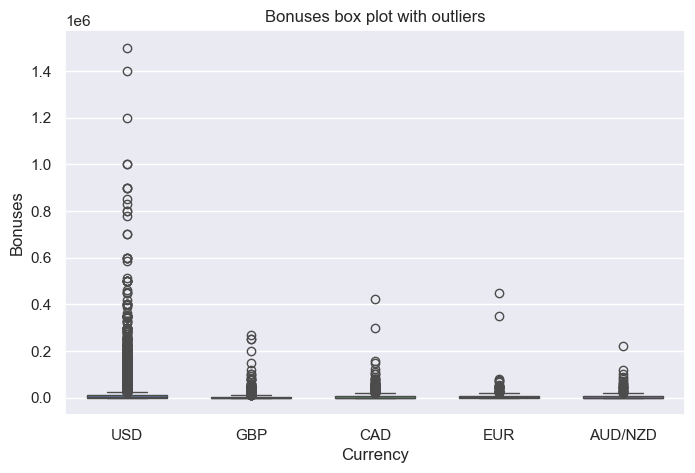

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df , 
            y = "Bonuses", 
            x="Currency",
            hue="Currency",
           gap=0.2,
           legend=False)
plt.title("Bonuses box plot with outliers")
plt.show()

# As we can see in the plot below, the column bonuses contain outliers.

**Important** - As we can see in the plot above, the column Bonuses contains outliers for each currency. Showing us that the mean is bias and **the best approach to replace null values in this situation is by using the median.**

In [ ]:
currencies = df["Currency"].unique() # Getting the unique currencies within the data frame

index = [] # list which we will use to store the index for null values per currency
medians = [] # median values to replace the null values per currency
for i in range(len(currencies)): # For loop to iterate in each currency
    index.append(df[df["Bonuses"].isnull()].query(f"Currency == '{currencies[i]}'").index) # Storing the null values' index into the index list 

for i in range(len(currencies)): # For loop to iterate in each currency
    medians.append(df[df["Currency"] == currencies[i]]["Bonuses"].median()) # Storing the median value for each currency in the medians list

for i in range(len(index)): # Changing the values
    df.loc[index[i],"Bonuses"] = medians[i] # Changing the null values for the median value of each currency

In [ ]:
df.isnull().sum() # Checking for null values

Age                   0
Industry              0
Job_title             0
Annual_salary         0
Bonuses               0
Currency              0
Country_of_work       0
US-State_of_work      0
City_of_work         76
YoE                   0
YoE_field             0
Education_Level     193
Gender              158
dtype: int64

Now that we have successfully replace the main null values, we will drop the rest of them.

In [ ]:
df = df.dropna() # Dropping null values
df.reset_index(drop=True, inplace=True) # Reseting the index
df.head() #Displaying the first 5 rows

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,USA,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,25-34,Computing or Tech,Change & Internal Communications Manager,"54,600",4000.0,GBP,UK,Not US Citizen,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",2000.0,USD,USA,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,USA,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman


In [ ]:
df.isnull().sum() # Checking for null values
# As we can see in the result below. The null values now are equal to 0 for each column

Age                 0
Industry            0
Job_title           0
Annual_salary       0
Bonuses             0
Currency            0
Country_of_work     0
US-State_of_work    0
City_of_work        0
YoE                 0
YoE_field           0
Education_Level     0
Gender              0
dtype: int64

In [ ]:
print(df.shape) # Checking the shape
print(f"\nThe data frame contains a total number of {df.shape[0]} rows and {df.shape[1]} columns") # Printing the result

(25442, 13)

The data frame contains a total number of 25442 rows and 13 columns


---

### Bonuses - Removing / replacing outliers

Firstly, I am going to calculate the number the outliers as a whole. If the outliers exceed the 10% i will use the **Winsorization** method, otherwise i will just **trim** them from the data frame.

In [ ]:
# Getting the Q1 and Q3 from the column Bonuses
Q1 = df['Bonuses'].quantile(0.25)
Q3 = df['Bonuses'].quantile(0.75)

# Interquartile range
IQR = Q3 - Q1

# Calculating the lower and upper limit
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR


# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df['Bonuses']>=upper)[0]
lower_array = np.where(df['Bonuses']<=lower)[0]

In [ ]:
total_outliers = len(upper_array) + len(lower_array) # Getting the total number of outliers

In [ ]:
print(f"The outliers represent the {round(total_outliers / len(df),2)} of the data in the column Bonuses") # Printing the result

The outliers represent the 0.14 of the data in the column Bonuses


Having this into mind, let's start working and replace the outlier by the upper and lower limit.

**Important** - To achieve this, i decided to take a deeper approach and slice the data frame, replace the outliers and then concat them all together.

In [ ]:
currencies = df["Currency"].unique() # Getting the unique values for the each currency
currencies

array(['USD', 'GBP', 'CAD', 'EUR', 'AUD/NZD'], dtype=object)

In [ ]:
dfs = [] # Variable to store the different data frames
for i in range(len(currencies)): # For loop to iterate for the different currencies
    dfs.append(df[df["Currency"] == currencies[i]]) # Using the append method to add the data frames into the dfs variable

In [ ]:
dfs[0].head() # We can access to the dataframes by giving an argument to the list indexer

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,USA,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",2000.0,USD,USA,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,USA,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
5,25-34,Education (Higher Education),Scholarly Publishing Librarian,"62,000",2000.0,USD,USA,New Hampshire,Hanover,8 - 10 years,2 - 4 years,Master's degree,Man


In [ ]:
for i in range(len(dfs)): # For loop to iterate by the diferent data frames within the list
    Q1 = dfs[i]['Bonuses'].quantile(0.25) # Getting the Q1 for each currency
    Q3 = dfs[i]['Bonuses'].quantile(0.75) # Getting the Q3 for each currency

    IQR = Q3 - Q1 # Getting the Interquartile range for each currency

    lower = Q1 - 1.5*IQR # lower limit
    upper = Q3 + 1.5*IQR # upper limit

    # using the np.where function in order to change the values regarding the the condition is true or false
    dfs[i].loc[:,"Bonuses"] = np.where(
              dfs[i]["Bonuses"] > upper, 
              upper, 
              np.where(
                  dfs[i]["Bonuses"] < lower, 
                  lower, 
                  dfs[i]["Bonuses"])
              )

In [ ]:
df = pd.concat(dfs, ignore_index = True) # Concatenating the dataframe 
df.reset_index(drop=True, inplace=True) # Restarting the index

In [ ]:
df["Bonuses"] = df["Bonuses"].astype("int") # Assigning Bonuses column as integer

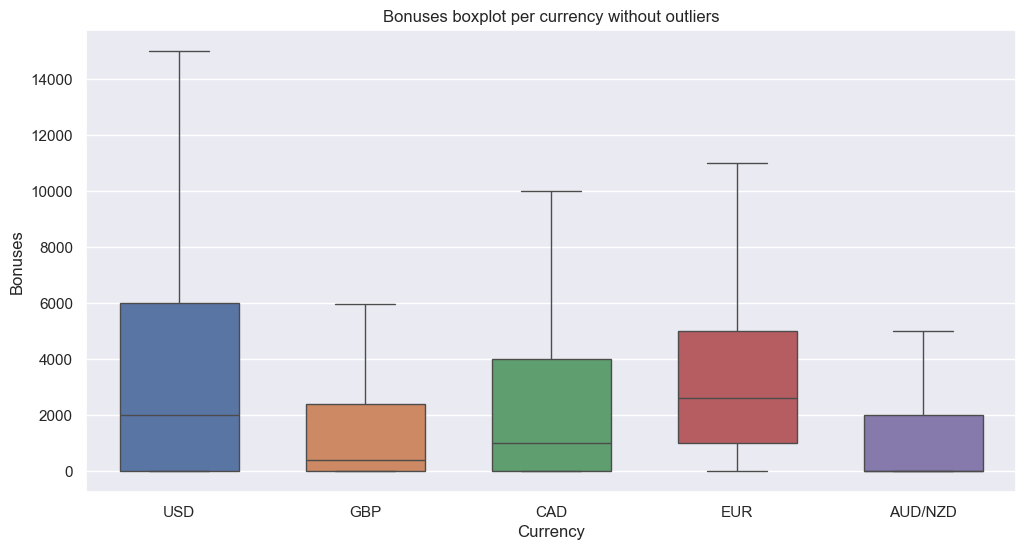

In [ ]:
# Bonuses box plot per currency
plt.figure(figsize=(12,6)) 
sns.boxplot(data=df , 
           y = "Bonuses", 
           x="Currency",
           hue="Currency",
           gap=0.2,
           legend=False,
           )
plt.title("Bonuses boxplot per currency without outliers")
plt.show()


- **Objective**: Compare the measure of central tendency from the column Bonuses per currency.
- **Why this plot**: We use the box plot to have an easy and quick access to the measure of central tendency
- **Learning**: By looking at the plot, we can highlight that the **highest median bonuse is held by euro earners while the lowest one for the GBP** earners. We can aslo see that **USD employees has the highest Q3 Bonuses and the maximum as well.**

---

### Annual salary

In [ ]:
df["Annual_salary"] = df["Annual_salary"].str.replace(",","") # Replacing the "," for nothing so i can convert the values to float
df["Annual_salary"] = df["Annual_salary"].astype("float") # asigning float format to the values within the column annual salary

# Important - I have tried to convert the values to integer but by doing it i get a change from the values. One of the values changes for no reason.
# The only way to make it work was drop the outliers and then convert the data from float to int

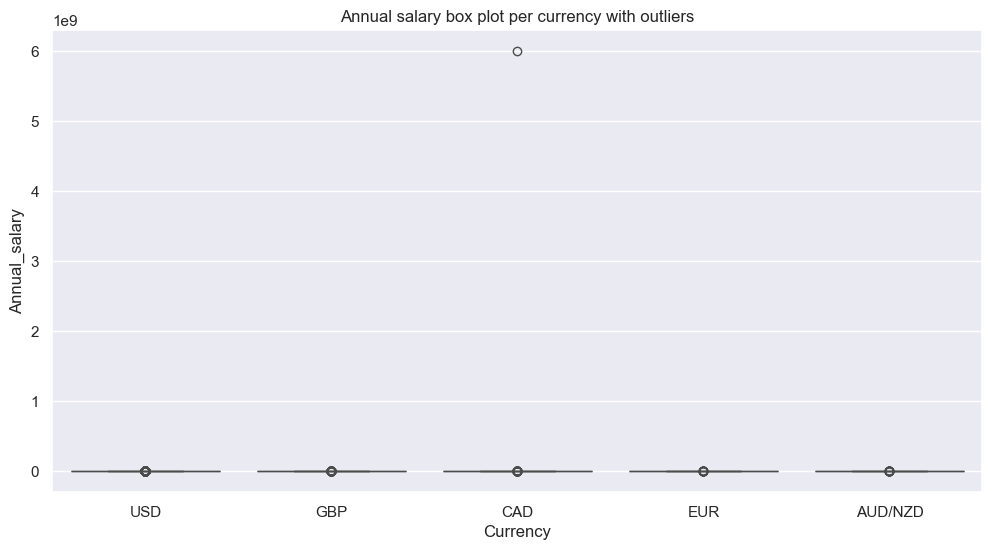

In [ ]:
plt.figure(figsize=(12,6)) 
sns.boxplot(data=df , y = "Annual_salary", hue="Currency", x="Currency") # Annual salary box plot per currency
plt.title("Annual salary box plot per currency with outliers") # Adding a title
plt.show()

By looking at the plot above, we can see that we have outliers within this column as well. Let's work as we did before and check the total number of outliers, their weight in the data frame and see which method we will use.

In [ ]:
currencies = df["Currency"].unique() # Getting the unique values for the each currency
currencies

array(['USD', 'GBP', 'CAD', 'EUR', 'AUD/NZD'], dtype=object)

In [ ]:
dfs = [] # Variable to store the different data frames
for i in range(len(currencies)): # For loop to iterate for the different currencies
    dfs.append(df[df["Currency"] == currencies[i]]) # Using the append method to add the data frames into the dfs variable

**Important** - The code below i found it on the document from classes from the **13th October - 19th October**. The document name is "Duplicates and outliers" it's on word file.

In [ ]:
upper_array = []
lower_array = []

for i in range(len(dfs)): # For loop to iterate by the diferent data frames within the list
    dfs[i].reset_index(drop=True, inplace=True) # Reseting the index for each data frame
    Q1 = dfs[i]['Annual_salary'].quantile(0.25) # Getting the Q1 for each currency
    Q3 = dfs[i]['Annual_salary'].quantile(0.75) # Getting the Q3 for each currency

    IQR = Q3 - Q1 # Getting the Interquartile range for each currency

    lower = Q1 - 1.5*IQR # lower limit
    upper = Q3 + 1.5*IQR # upper limit

    upper_array.append(np.where(dfs[i]['Annual_salary']>=upper)[0])
    lower_array.append(np.where(dfs[i]['Annual_salary']<=lower)[0])

In [ ]:
total_outs = []
for i in range(len(currencies)):
    total_outliers = len(upper_array[i])  + len(lower_array[i])
    total_outs.append(total_outliers)
    print(f"The total number of outliers for the currency {currencies[i]} is = {total_outliers}")

print("\n")
for i in range(len(currencies)):
    total_outliers = len(upper_array[i])  + len(lower_array[i])
    print(f"The outliers for the currency {currencies[i]} {round(total_outliers / len(dfs[i]),2)} of the data")

print(f"\nThe outliers represent {round(sum(total_outs) / len(df),2)} of the data on the column Annual salary.")


The total number of outliers for the currency USD is = 851
The total number of outliers for the currency GBP is = 75
The total number of outliers for the currency CAD is = 53
The total number of outliers for the currency EUR is = 23
The total number of outliers for the currency AUD/NZD is = 27


The outliers for the currency USD 0.04 of the data
The outliers for the currency GBP 0.05 of the data
The outliers for the currency CAD 0.03 of the data
The outliers for the currency EUR 0.04 of the data
The outliers for the currency AUD/NZD 0.06 of the data

The outliers represent 0.04 of the data on the column Annual salary.


As we can see, the total number of outliers within the column "Annual salary" represent only the 4% of the values. Which means we can proceed by removing them using the trimming method.

In [ ]:
currencies = df["Currency"].unique() # Getting the unique values for the each currency
currencies

array(['USD', 'GBP', 'CAD', 'EUR', 'AUD/NZD'], dtype=object)

In [ ]:
dfs = [] # Variable to store the different data frames
for i in range(len(currencies)): # For loop to iterate for the different currencies
    dfs.append(df[df["Currency"] == currencies[i]]) # Using the append method to add the data frames into the dfs variable

**Important** - The code below i found it on the document from classes from the **13th October - 19th October**. The document name is "Duplicates and outliers" it's on word file.

In [ ]:
pd.options.mode.copy_on_write = True

for i in range(len(dfs)): # For loop to iterate by the diferent data frames within the list
    dfs[i].reset_index(drop=True, inplace=True) # Reseting the index for each data frame
    Q1 = dfs[i]['Annual_salary'].quantile(0.25) # Getting the Q1 for each currency
    Q3 = dfs[i]['Annual_salary'].quantile(0.75) # Getting the Q3 for each currency

    IQR = Q3 - Q1 # Getting the Interquartile range for each currency

    lower = Q1 - 1.5*IQR # lower limit
    upper = Q3 + 1.5*IQR # upper limit

    upper_array = np.where(dfs[i]['Annual_salary']>=upper)[0]
    lower_array = np.where(dfs[i]['Annual_salary']<=lower)[0]

    dfs[i].drop(index=upper_array, inplace=True)
    dfs[i].drop(index=lower_array, inplace=True)

# I am receiving an error from the pandas documentation. It 
# See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
#   dfs[i].drop(index=upper_array, inplace=True)
# C:\Users\leona\AppData\Local\Temp\ipykernel_28492\2979297846.py:15: SettingWithCopyWarning: 
# A value is trying to be set on a copy of a slice from a DataFrame

# The function works but the error keeps displaying, in order to avoid it i need to set the next code
#pd.options.mode.copy_on_write = True
# I was able to avoid the error by reading the page: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df = pd.concat(dfs, ignore_index=True)

In [ ]:
# Setting the annual salary column as integer
df["Annual_salary"] = df["Annual_salary"].astype("int")
# Reseting the index
df.reset_index(drop=True, inplace=True)

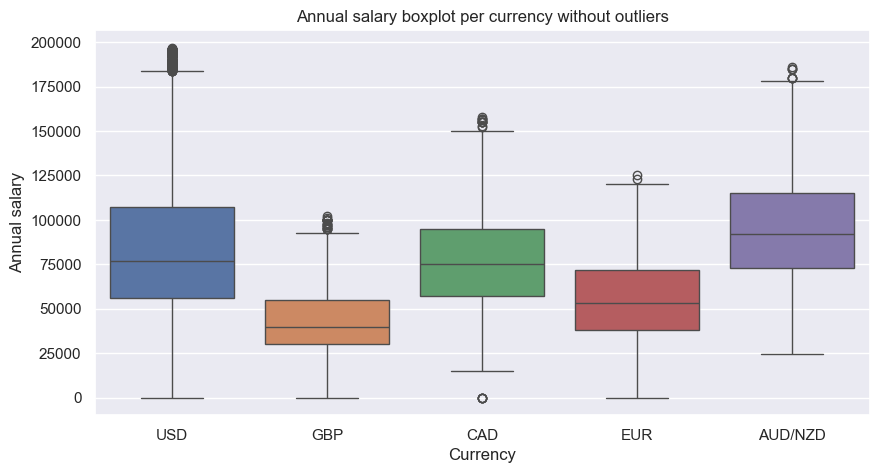

In [ ]:
plt.figure(figsize=(10,5)) #setting a figure size
sns.boxplot(data=df , y = "Annual_salary", hue="Currency", x="Currency") # Annual salary box plot per currency
plt.title("Annual salary boxplot per currency without outliers") # Title
plt.ylabel("Annual salary") # y label
plt.show()

- **Objective**: Compare the measure of central tendency from the column Annual salary column per currency.
- **Why this plot**: We use the box plot to have an easy and quick access to the measure of central tendency
- **Learning**: By looking at the plot, we can highlight that the **highest median salary is held by AUD/NZD employees** while the lowest one is held by GBP.

-----

# 4) Question and answer - In this section we are going to set questions and answer them

---

### Age - ¿What are the absolute frequencies and relative frequencies?

In [ ]:
df_age = df["Age"].value_counts() # Counting all the values and obtaining the absolute frequency
df_age = df_age.reset_index() # Reseting the index 
df_age["Weight"] = round(df_age["count"] / len(df["Age"]),2)*100 # Calculating the relative frequency
df_age.set_index("Age",inplace=True) # Setting the age column as index
df_age # displaying the dataframe


,count,Weight
Age,,
25-34,11192,46.0
35-44,8523,35.0
45-54,2704,11.0
18-24,1080,4.0
55-64,827,3.0
65 or over,79,0.0
under 18,8,0.0


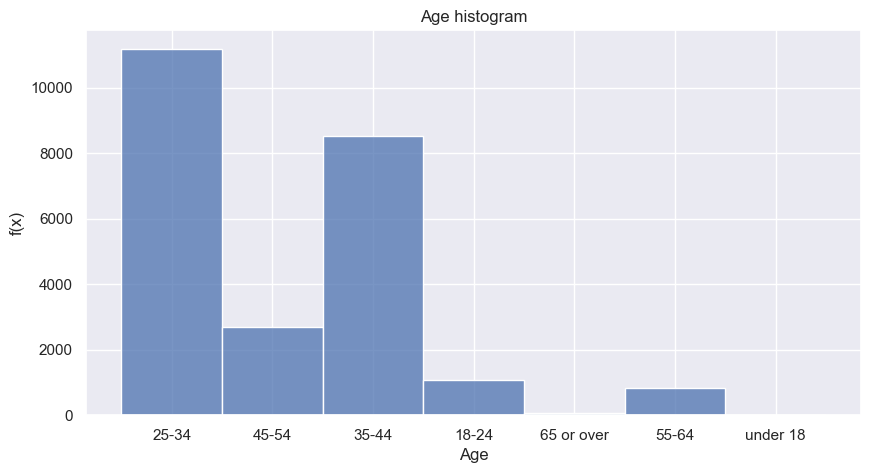

In [ ]:
plt.figure(figsize=(10,5)) # figure size
sns.histplot(data=df,x="Age") # Histogram
plt.title("Age histogram") # Title
plt.ylabel("f(x)") # Y label
plt.show()

As we can see on the plot above, the x values are not organised as they should of. The reason why of this is the type of data, the age column is interval type. We need to transform the values into numbers. To achieve this, we are going to use descritizacion.

In [ ]:
# Creating the function
def custom_descritizacion(value):
    if value == "under 18":
        return 1
    elif value == "18-24":
        return 2
    elif value == "25-34":
        return 3
    elif value == "35-44":
        return 4
    elif value == "45-54":
        return 5
    elif value == "55-64":
        return 6
    elif value == "65 or over":
        return 7

In [ ]:
df_age = df.copy() # Making a copy of the actual data frame so we do not alter the original
df_age["Age_values"]=df_age["Age"].apply(custom_descritizacion) # Applying the function

In [ ]:
df_age[["Age","Age_values"]].head() # Checking the result

,Age,Age_values
0,25-34,3
1,25-34,3
2,25-34,3
3,25-34,3
4,25-34,3


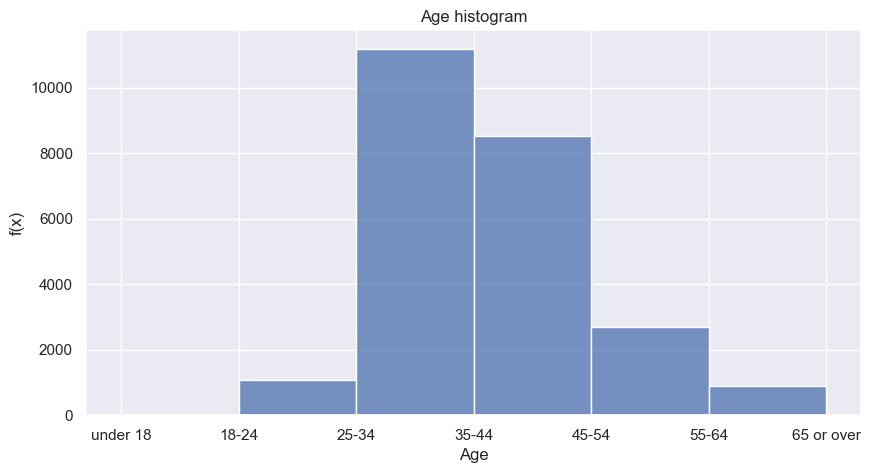

In [ ]:
index = df["Age"].unique()   # Obtaining the values to change the xticks

# Plotting the histogram again
plt.figure(figsize=(10,5)) # figure size
sns.histplot(data=df_age,x="Age_values", binwidth=1) # plotting the histogram
plt.title("Age histogram") # title
plt.xticks(ticks = df_age["Age_values"].unique(),labels = index) # xticks labels
plt.xlabel("Age") 
plt.ylabel("f(x)")
plt.show()

- **Objective**: Check if the data is skewed or simmetrical and find the age range with the highest frequency
- **Why this plot**: We use a histogram to check the absolute and relative frequency for each value.
- **Learning:**: We can see that the data is slightly right skewed and that the age range with the highest frequency is 25-34 years old 

### Age / Annual salary - ¿What are the measures of central tendency of each group age?

**Important** - As we noticed before, we have different types of currencies. We are going to calculate the measure of central tendency for each as well.

In [ ]:
currencies = df["Currency"].unique() # Getting the unique values for each currency
dfs = [] # variable to store the data frames

for i in range(len(currencies)): # for loop to iterate
    dfs.append(df[df["Currency"] == currencies[i]]) # adding the dataframes into the variable

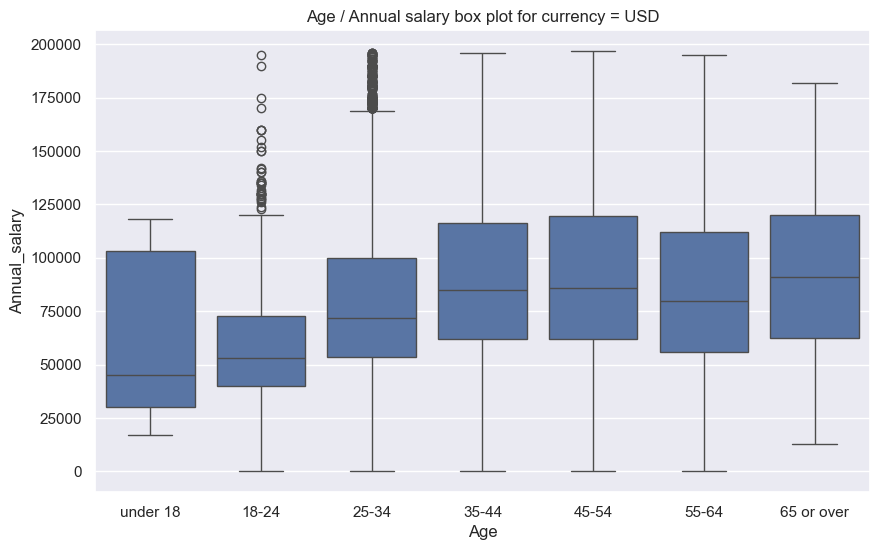

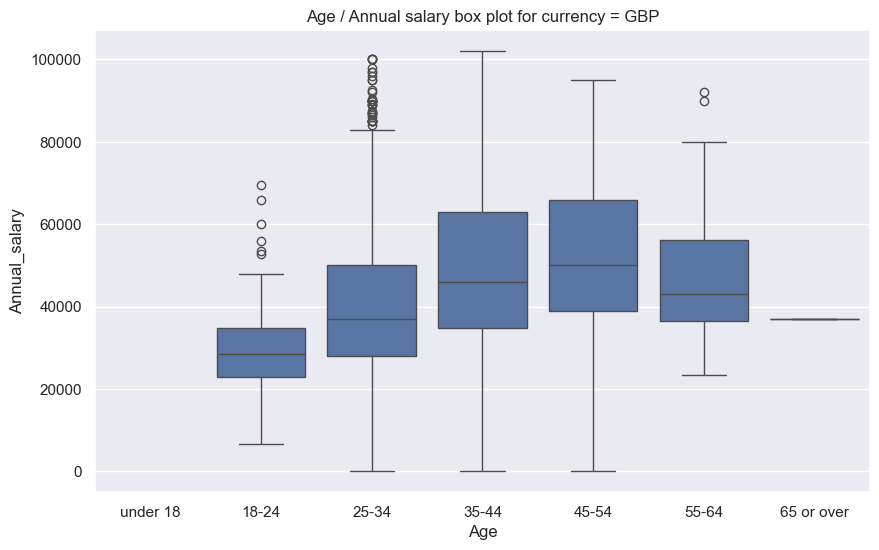

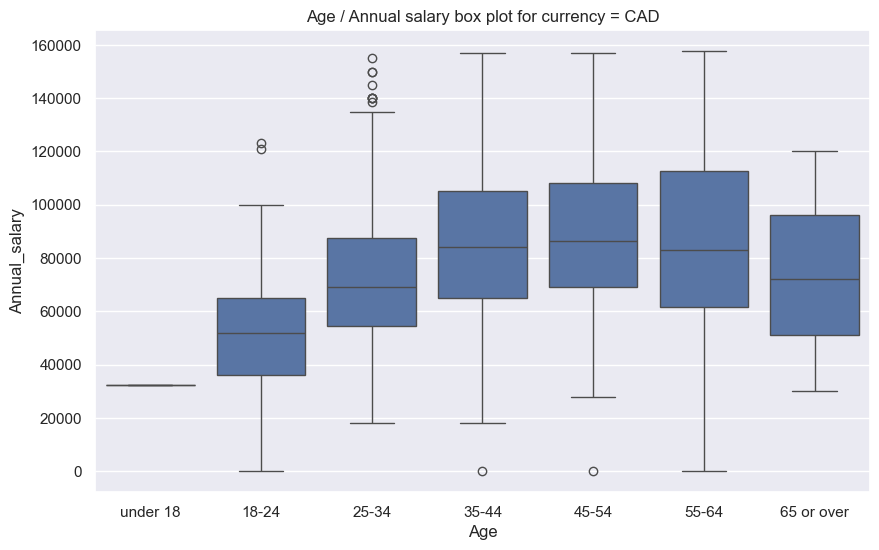

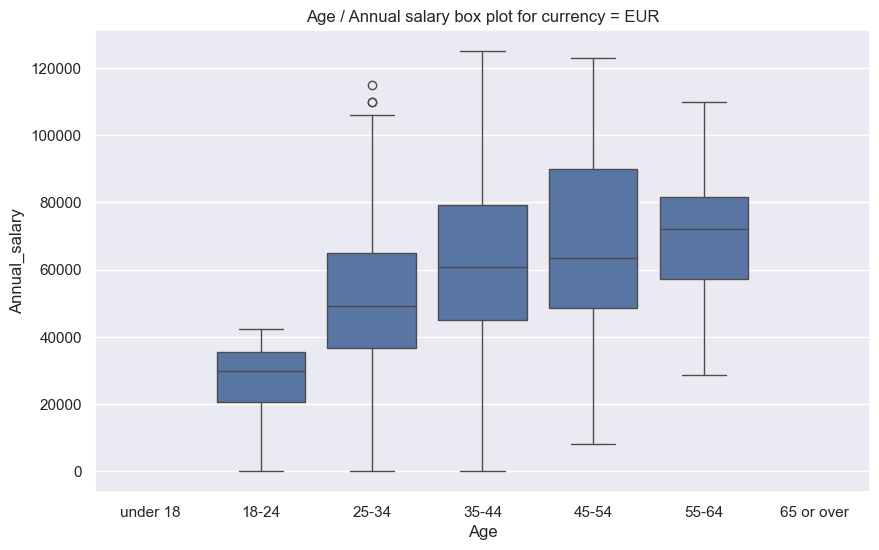

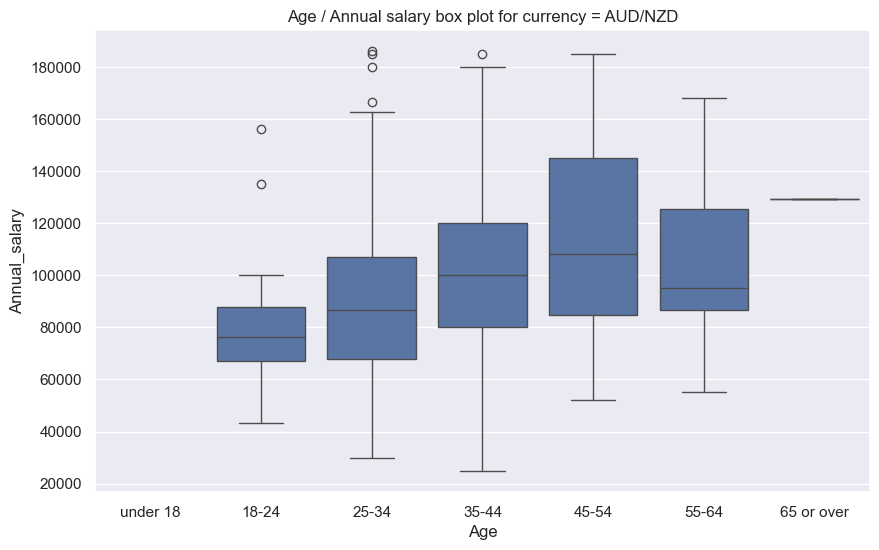

In [ ]:
age_range_order = ['under 18','18-24', '25-34', '35-44', '45-54', '55-64', '65 or over',] # Ordering the box plot by interval
for i in range(len(dfs)): # for loop to iterate
    plt.figure(figsize=(10,6)) # figure size
    sns.boxplot(data=dfs[i], x=dfs[i]["Age"], y=dfs[i]["Annual_salary"],order=age_range_order) # box plot
    plt.title(f"Age / Annual salary box plot for currency = {currencies[i]}") # title
    plt.show()

- **Objective**: Compare the measure of central tendency for each age range having under consideration the currency in which they earn 
- **Why this plot**: We use the box plot to have an easy and quick access to the measure of central tendency
- **Answer**: By looking at the plots above, we can say that over the years the **median salary increases for the employees that earns in USD dollars**, for the employees under 18 their median salary is less than 50K, by the age of 18-24 is above 50K, between 25-34 it gets closer to 75K, 35-44 roughly 85K. It decreases a bit between the age of 55-64 and by 65 or more the median salary is the highest one for this group (USD employee's earners)
- **Learning:**: We can highlight the difference between the median salary between the different currencies. **The median salary for a employee between 25-34 years old that earns in USD is above 50k while for an employee that earns in GBP is roughly 37k, for a employee that earns in CAD is nearly 75K and for one that earns in euros is 50K, and for AUD/NZD earners is over 80K**

---

### Industry / Annual salary - ¿Which are the top-10-industrdies to work in regarding frequency? Check as well for top-10 mean salary per currency.

In [ ]:
df_industries = df["Industry"].value_counts().head(10) # absolute frequency top 10
df_industries = df_industries.reset_index() # reseting index
df_industries["Weight"] = round(df_industries["count"] / len(df),2)*100 # Relative frequencies
df_industries.set_index("Industry",inplace=True) # setting industry as index3
df_industries # displaying data frame

,count,Weight
Industry,,
Computing or Tech,4024,16.0
Education (Higher Education),2345,10.0
Nonprofits,2324,10.0
Government and Public Administration,1809,7.0
Health care,1742,7.0
"Accounting, Banking & Finance",1662,7.0
Engineering or Manufacturing,1591,7.0
"Marketing, Advertising & PR",1047,4.0
Law,900,4.0


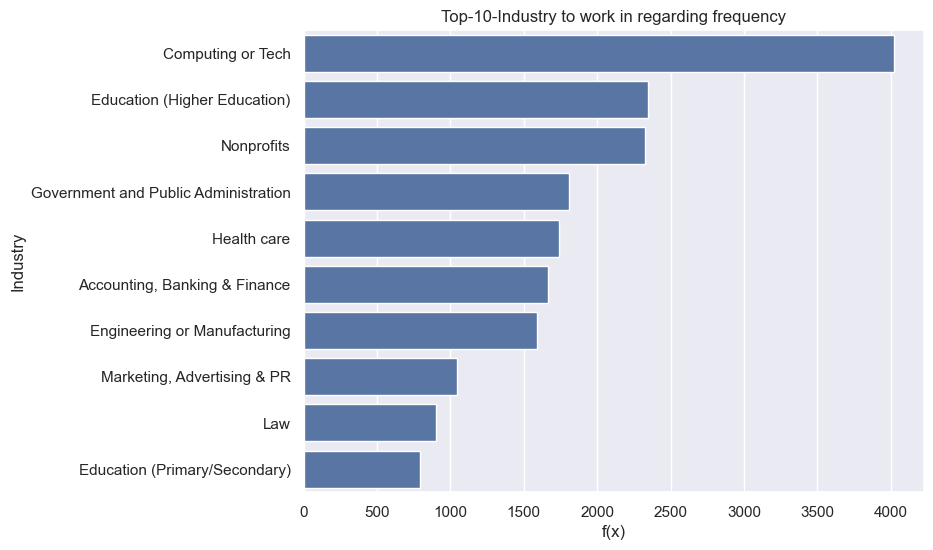

In [ ]:
plt.figure(figsize=(8,6)) # Figure size
sns.barplot(data=df_industries, y=df_industries.index, x="count") # plotting bar plot
plt.title("Top-10-Industry to work in regarding frequency") # title
plt.xlabel("f(x)") # xlabel
plt.show()

- **Objective**: Check which are the top-10-industries by frequency
- **Why this plot**: Bar charts crearly show frequency counts
- **Learning:**: By looking at the chart we can see that the industry with the highest frequency is **Computing or tech**, the second one is **Higher education**, and the third one is **nonprofits**.

### Top-10-Industry to work in regarding mean salary / currency

In [ ]:
dfs_industry_mean = [] # variable to store the datafrrames

for i in range(len(dfs)): # for loop to iterate
    dfs_industry_mean.append(dfs[i].groupby("Industry")["Annual_salary"].mean().round(2).sort_values(ascending=False).head(10)) # groupping by industry
# and annual salary per data frame

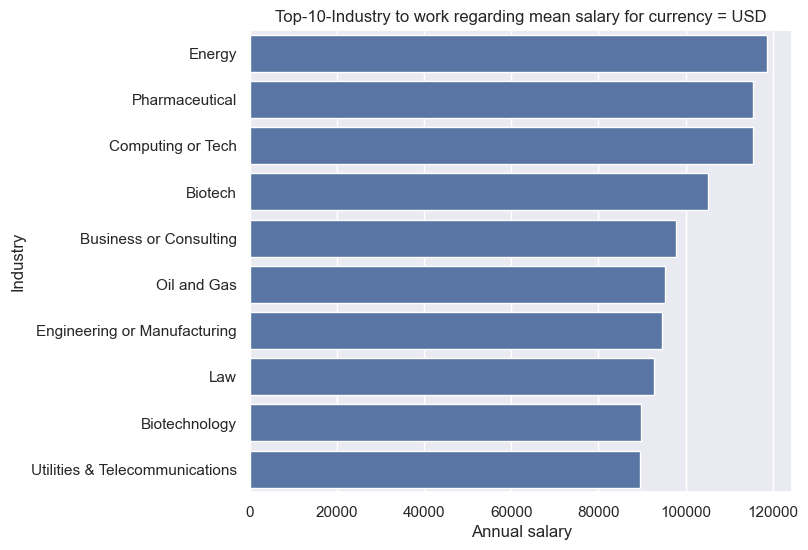

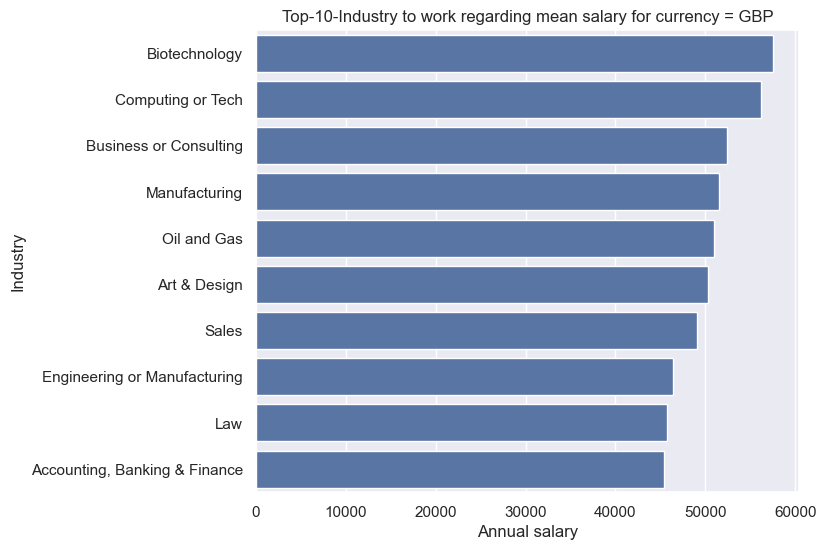

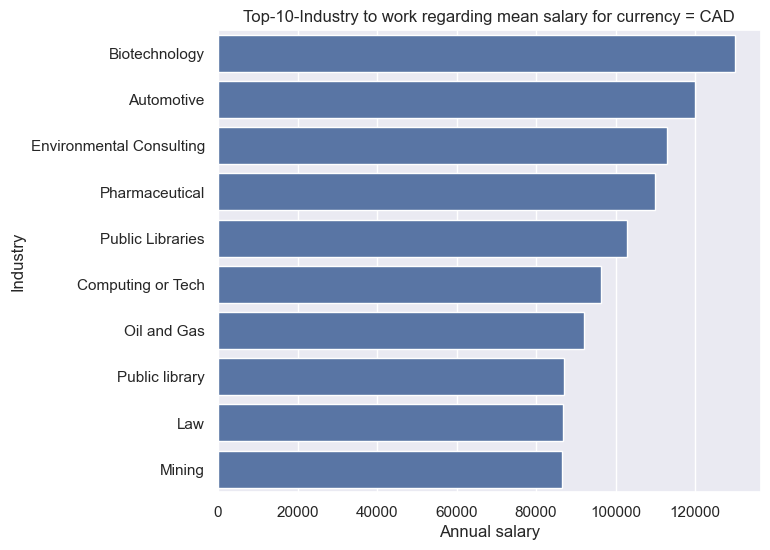

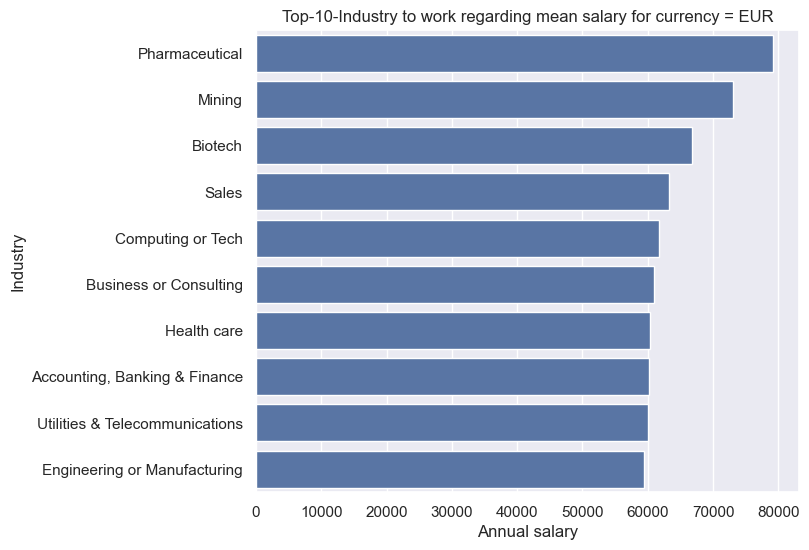

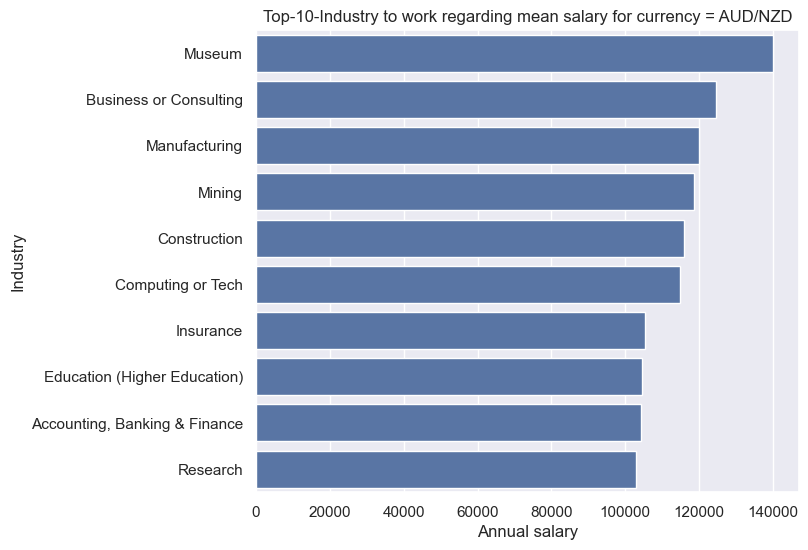

In [ ]:
for i in range(len(dfs_industry_mean)): # for loop to iterate by each data frame 
    plt.figure(figsize=(7,6)) # figure size
    sns.barplot(data = dfs_industry_mean[i], orient="h") # bar plot 
    plt.title(f"Top-10-Industry to work regarding mean salary for currency = {currencies[i]}") # title
    plt.xlabel("Annual salary") # x label
    plt.show()

# I am going to change the values from the pharmaceutical rows

- **Objective**: Compare the results obtained from the last chart (top-10-indsutries by frequency) against to the top-10-industries to work by mean salary per currency.
- **Why this plot**: Bar plots provide us an easy view of the data for numeric values.
- **Learning:**: The best industry to work **by frequency is computing or tech** while the best for the **mean salary in for USD earners is Energy**, for **GBP and CAD is Biotechnology**, for **EUR is Phamaceuticals**, and for **AUD / NZD is museum**. 


---

### Gender - ¿What are the absolute frequencies and relative frequencies?

In [ ]:
df_gender = df["Gender"].value_counts() # absolute frequency by gender
df_gender = df_gender.reset_index() # reseting index
df_gender["Weight"] = round(df_gender["count"] / len(df["Age"]),2)*100 # relative frequency
df_gender.set_index("Gender",inplace=True) # setting gender as index
df_gender


,count,Weight
Gender,,
Woman,18926,78.0
Man,4568,19.0
Non-binary,661,3.0
Other or prefer not to answer,258,1.0


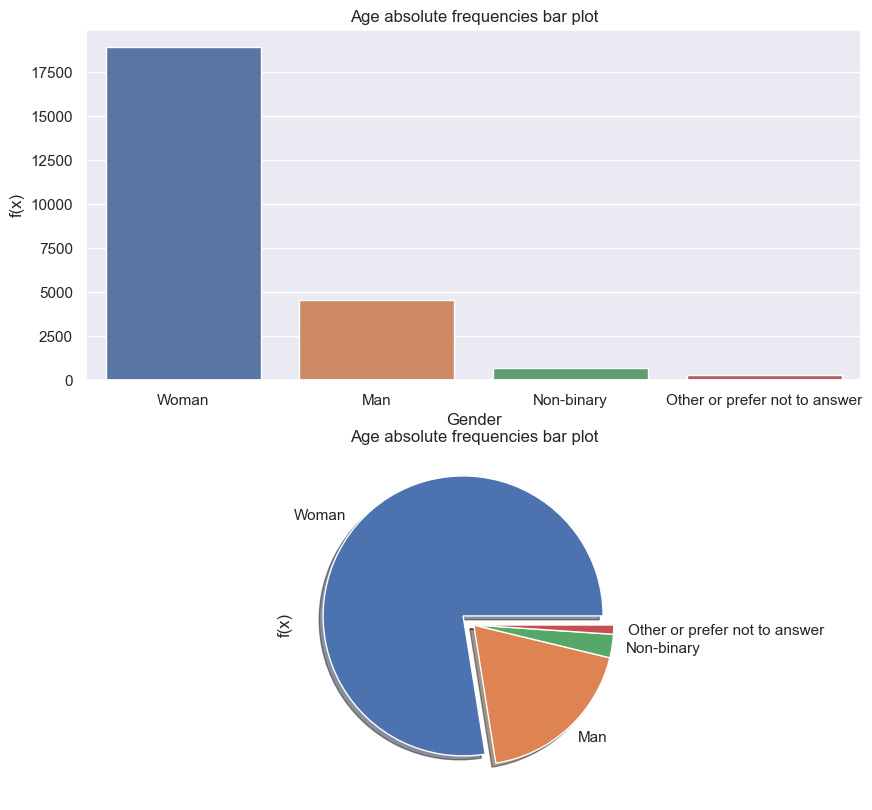

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sns.barplot(data=df_gender, x=df_gender.index, y="count", hue=df_gender.index) # plotting bar plot
plt.title("Age absolute frequencies bar plot")
plt.ylabel("f(x)")
plt.subplot(2,1,2)
explode = [0.1,0,0,0]
labels_gender = df_gender["count"].index
plt.pie(df_gender["count"], labels=labels_gender, explode = explode, shadow=True) # plotting pie plot
plt.title("Age absolute frequencies bar plot")
plt.ylabel("f(x)")
plt.show()
plt.show()

- **Objective**: Check the absolute and relative frequencies from the column gender.
- **Why this plot**: Pie plots are good to quickly understand how much proportion of the data is taken by a value while bar plots are good to see the quantity (count).
- **Learning:**: Women predomine on the data set over 75% while men are nearly a 25%. The total number of women is over 18000 and men is nearly 5000.

### Annual salary / Gender / Currency - Box plot

In [ ]:
currencies = df["Currency"].unique() 
dfs = []

for i in range(len(currencies)):
    dfs.append(df[df["Currency"] == currencies[i]])

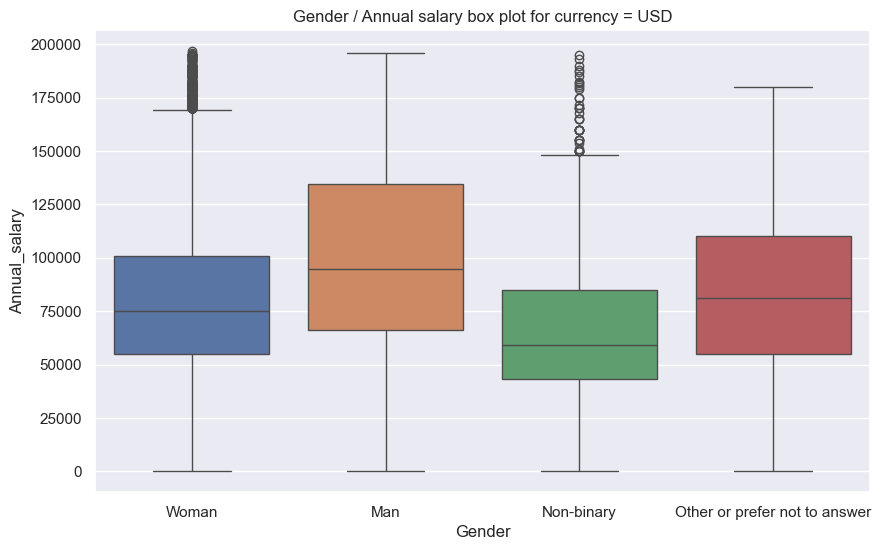

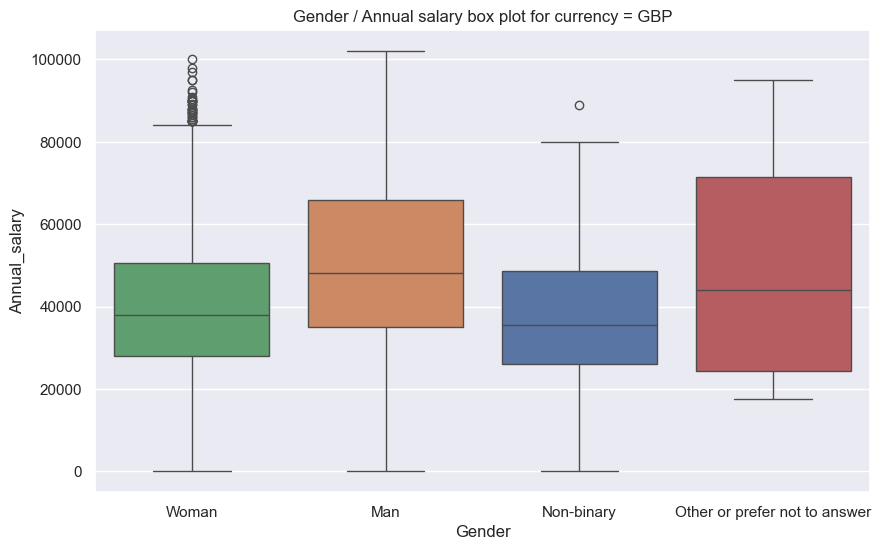

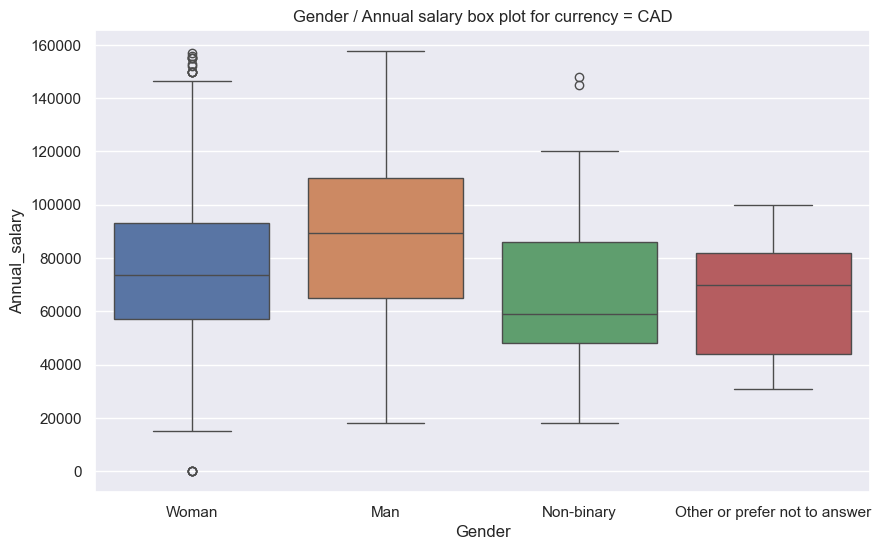

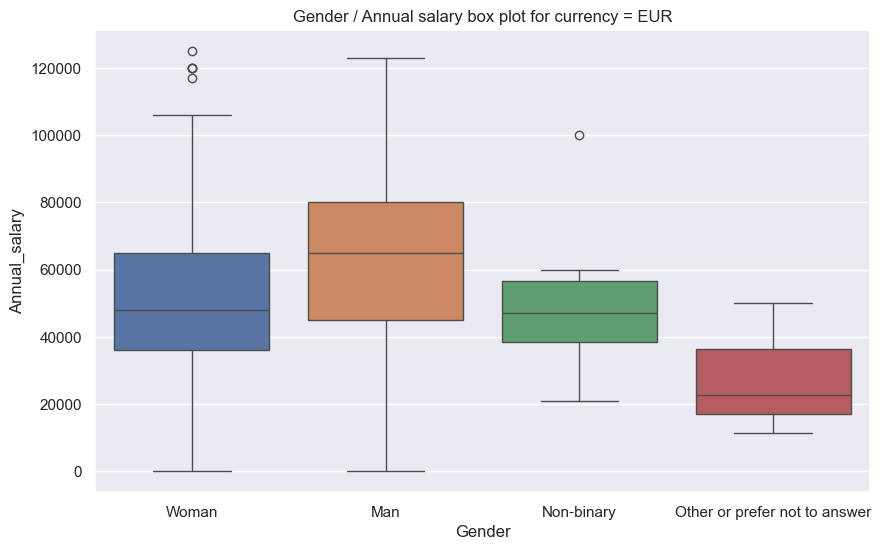

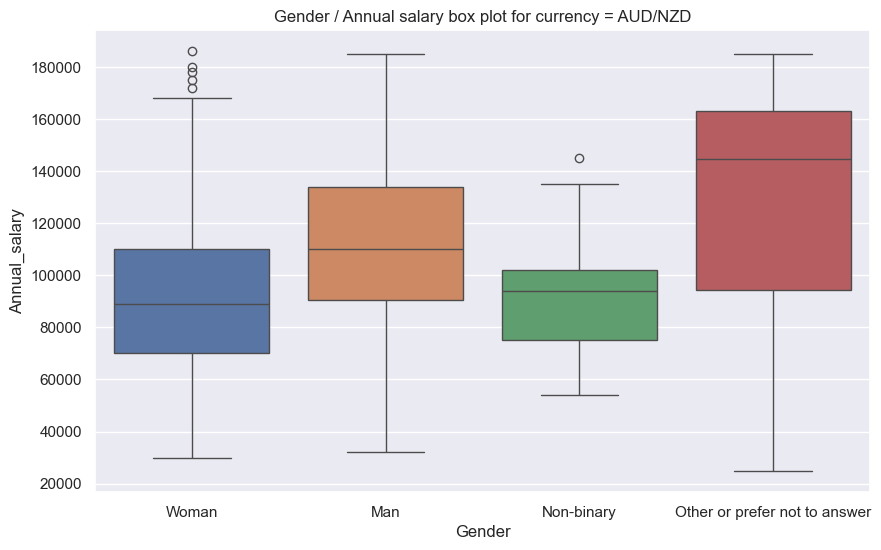

In [ ]:
Order = df["Gender"].unique()
for i in range(len(dfs)):
    plt.figure(figsize=(10,6))
    sns.boxplot(data=dfs[i], hue=dfs[i]["Gender"], y=dfs[i]["Annual_salary"], x=dfs[i]["Gender"], order=Order)
    plt.title(f"Gender / Annual salary box plot for currency = {currencies[i]}")
    plt.show()

 - **Objective**: Check the measure of central tendency for each gender and compare them
- **Why this plot**: Box plot are useful to check the 5 numbers (Min, Q1, median, Q3, and max), in another words, the measures of central tendency.
- **Learning:**: The men has the highest median salary in every single currency.

----

### Country of work - Which are Top-5 countries of work by frequency? check also the top 5 country by mean salary and the total number of NON US workers

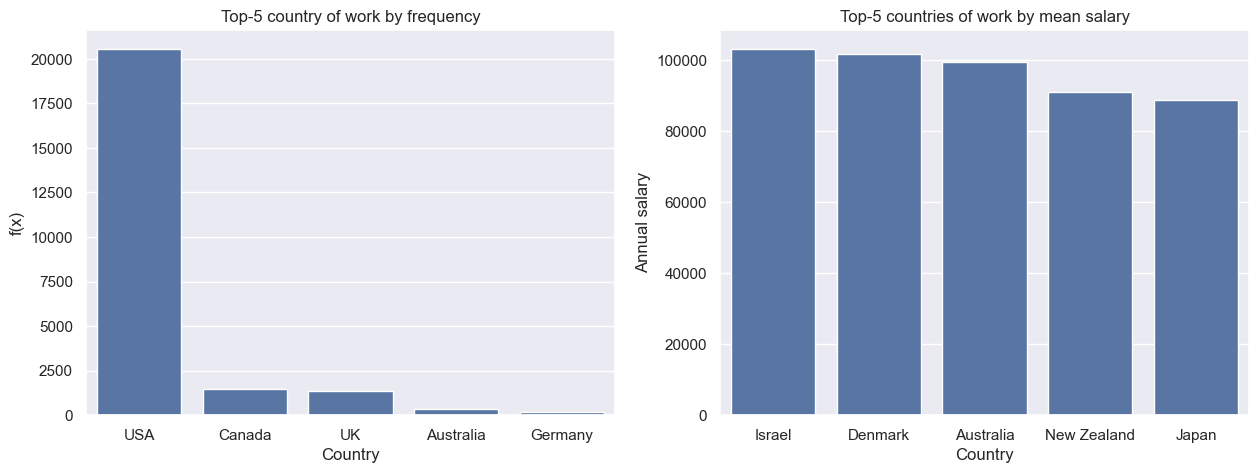

In [ ]:
df_CoW = df["Country_of_work"].value_counts().head()
plt.figure(figsize=(15,5))

# Plot 1
plt.subplot(1,2,1)
sns.barplot(data=df_CoW)
plt.ylabel("f(x)")
plt.xlabel("Country")
plt.title("Top-5 country of work by frequency")
# Plot 2
df_CoW_mean = df.groupby("Country_of_work")["Annual_salary"].mean().round(2).sort_values(ascending=False).head()
plt.subplot(1,2,2)
sns.barplot(data=df_CoW_mean)
plt.ylabel("Annual salary")
plt.xlabel("Country")
plt.title("Top-5 countries of work by mean salary")
plt.show()

- **Objective**: Check the absolute frequency for the top 5 countries to work and compare the top 5 countries to work by mean salary.
- **Why this plot**: We use a bar chart because are helpful to understand quantitave and we can easily see the difference betwen the values.
- **Learning:**: More than 20 thousand employees in the data frame work in the USA and the highest mean salary is hold by the sirael workers.

---

### Education - Checking for absolute and relative frequency and obtaining the mean salary for each education level by currency

In [ ]:
df_education = df["Education_Level"].value_counts() # counting the values for each level
df_education = df_education.reset_index() # reseting index
df_education["Weight"] = round(df_education["count"] / len(df["Age"]),2)*100 # relative frequency
df_education.set_index("Education_Level",inplace=True) # setting education level as index
df_education # displaying data frame

,count,Weight
Education_Level,,
College degree,12058,49.0
Master's degree,7821,32.0
Some college,1807,7.0
PhD,1176,5.0
"Professional degree (MD, JD, etc.)",1022,4.0
High School,529,2.0


In [ ]:
df_edu_median = df.groupby(["Currency","Education_Level"])["Annual_salary"].mean().round(2) # groupping by currency and education level and obtaining the mean salary
df_edu_median = pd.DataFrame(df_edu_median) # Converting it into data frame 
df_edu_median = df_edu_median.reset_index()  # reseting index
df_edu_median.head() # displayibng the first 5 rows

,Currency,Education_Level,Annual_salary
0,AUD/NZD,College degree,97354.51
1,AUD/NZD,High School,87185.86
2,AUD/NZD,Master's degree,99830.14
3,AUD/NZD,PhD,100429.48
4,AUD/NZD,"Professional degree (MD, JD, etc.)",112516.67


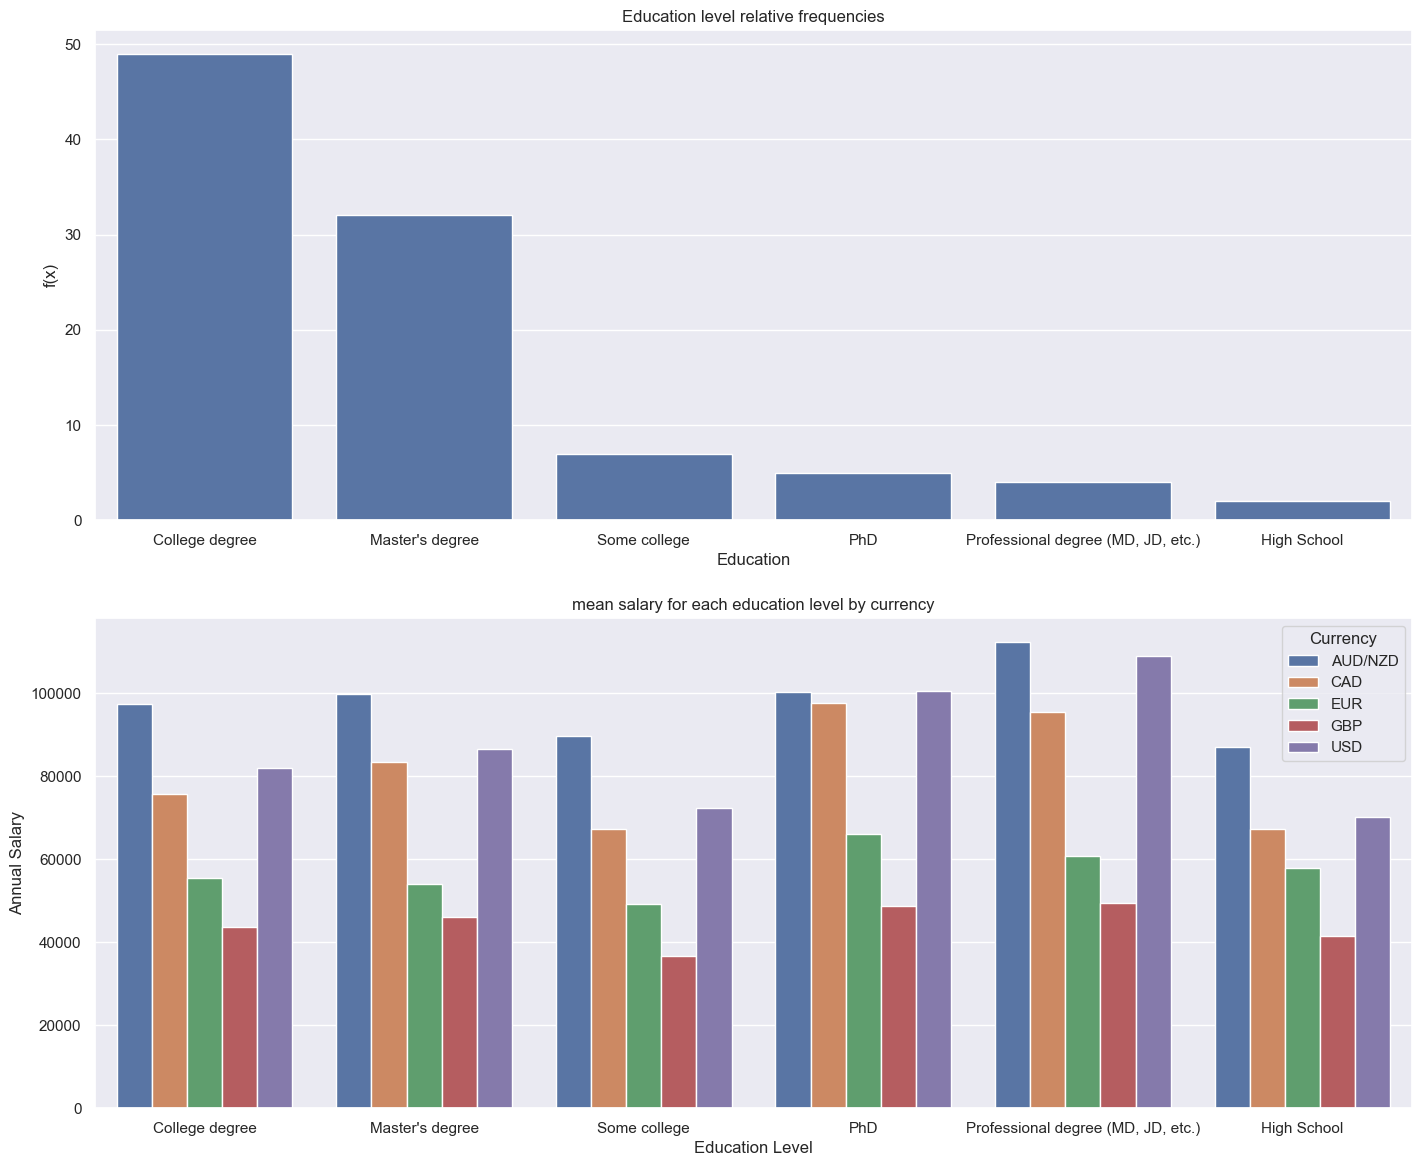

In [ ]:
plt.figure(figsize=(17,14)) 
plt.subplot(2,1,1)
sns.barplot(data=df_education, y="Weight", x=df_education.index) # plotting relative freuency
plt.title("Education level relative frequencies")
plt.xlabel("Education")
plt.ylabel("f(x)")

bar_order = ['College degree', "Master's degree", 'Some college','PhD', 'Professional degree (MD, JD, etc.)','High School']
plt.subplot(2,1,2)
sns.barplot(data=df_edu_median,y="Annual_salary",x="Education_Level",hue="Currency",legend=True,order=bar_order) # mean salary for each level by currency
plt.title("mean salary for each education level by currency")
plt.ylabel("Annual Salary")
plt.xlabel("Education Level")
plt.show()

- **Objective**: Check the relative frequencies for each education level and compare the mean salary for each one of them per currency. 
- **Why this plot**: We use a bar chart because are helpful to understand quantitive and we can easily see the difference betwen the values.
- **Learning:**: **Almost 50% of the employees in the data set have a college degree**. The highest mean salary for the categories College degree and master is for the currency AUD / NZD. For the category Phd is for CAD. For Professional degree and high school is AUD/NZD.

----

### Annual salary / Age - checking for correlation between these 2 columns.

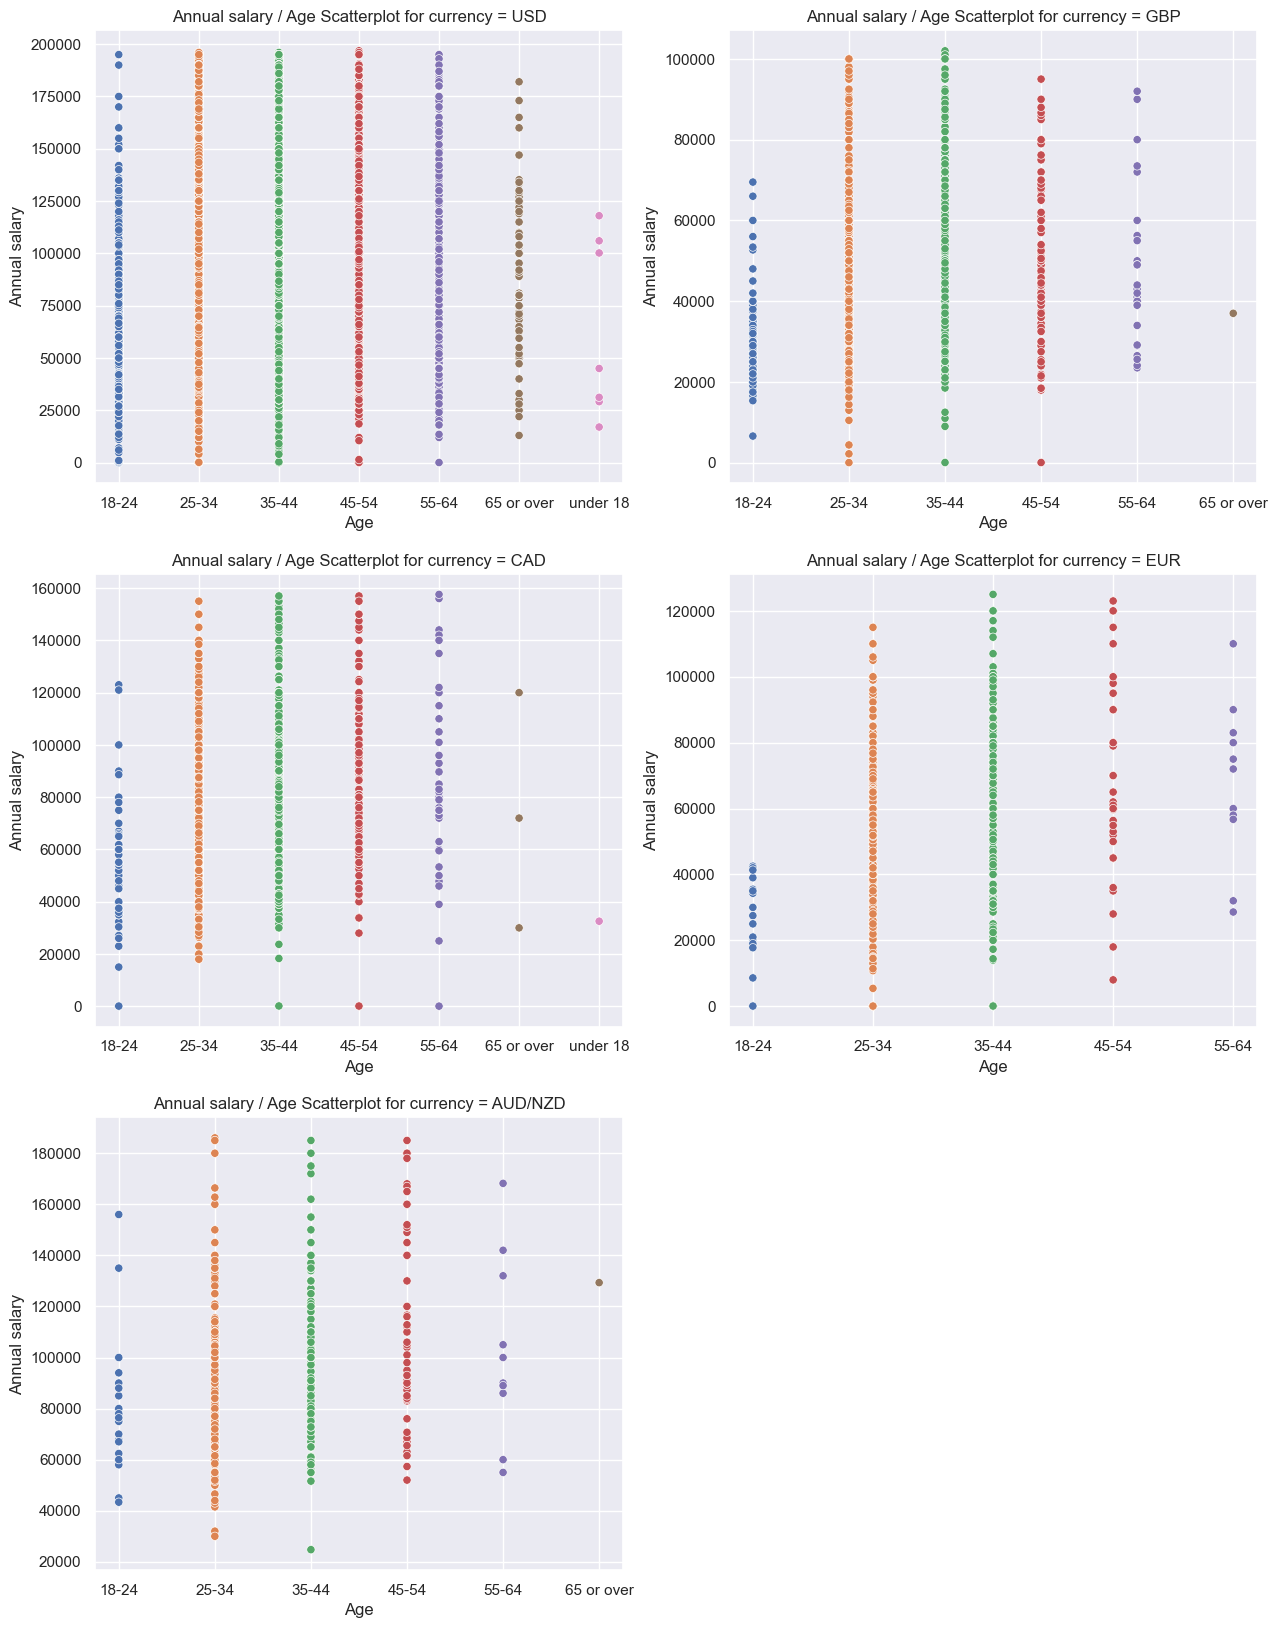

In [ ]:
currencies = df["Currency"].unique()
currencies

dfs = []

for i in range(len(currencies)):
    dfs.append(df[df["Currency"]==currencies[i]].sort_values(by="Age").reset_index(drop=True))


plt.figure(figsize=(15,20))
for i in range(len(dfs)):
    location = 1+i
    plt.subplot(3,2,location)
    sns.scatterplot(data=dfs[i], x="Age", y="Annual_salary",hue="Age",legend=False)
    plt.ylabel("Annual salary")
    plt.title(f"Annual salary / Age Scatterplot for currency = {currencies[i]}")

After looking at the graphs i figured out that is really hard to understand the data by using this plot. That's why i decided to go thourgh a different approach and plot a heat map.

# 5) Preparing for machine learning 

In this section we will transform categorical data into numerical using the sklearn library. Once we achieve this, we will proceed to plot a heat map and execute feature selection.

### Encoding

In [ ]:
df_cor = df.copy() # Making a copy of the data frame
columns = df_cor.select_dtypes(include="object").columns # Selecting the type object columns
le=preproc.LabelEncoder() # String the label encoder into a variable

In [ ]:
for i in range(len(columns)): # Using a for loop to iterate over the columns and apply the enconder and transfor the categorical data into numerical
    df_cor[columns[i]] = le.fit_transform(df_cor[columns[i]])

df_cor.head() # Displaying the first 5 rows

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,1,11,8291,55000,0,4,19,73,302,6,6,2,3
1,1,0,6303,34000,2000,4,19,113,522,2,2,0,3
2,1,32,7640,62000,3000,4,19,123,1880,7,6,0,3
3,1,0,152,60000,7000,4,19,111,1186,7,6,0,3
4,1,11,8556,62000,2000,4,19,88,1233,7,2,2,0


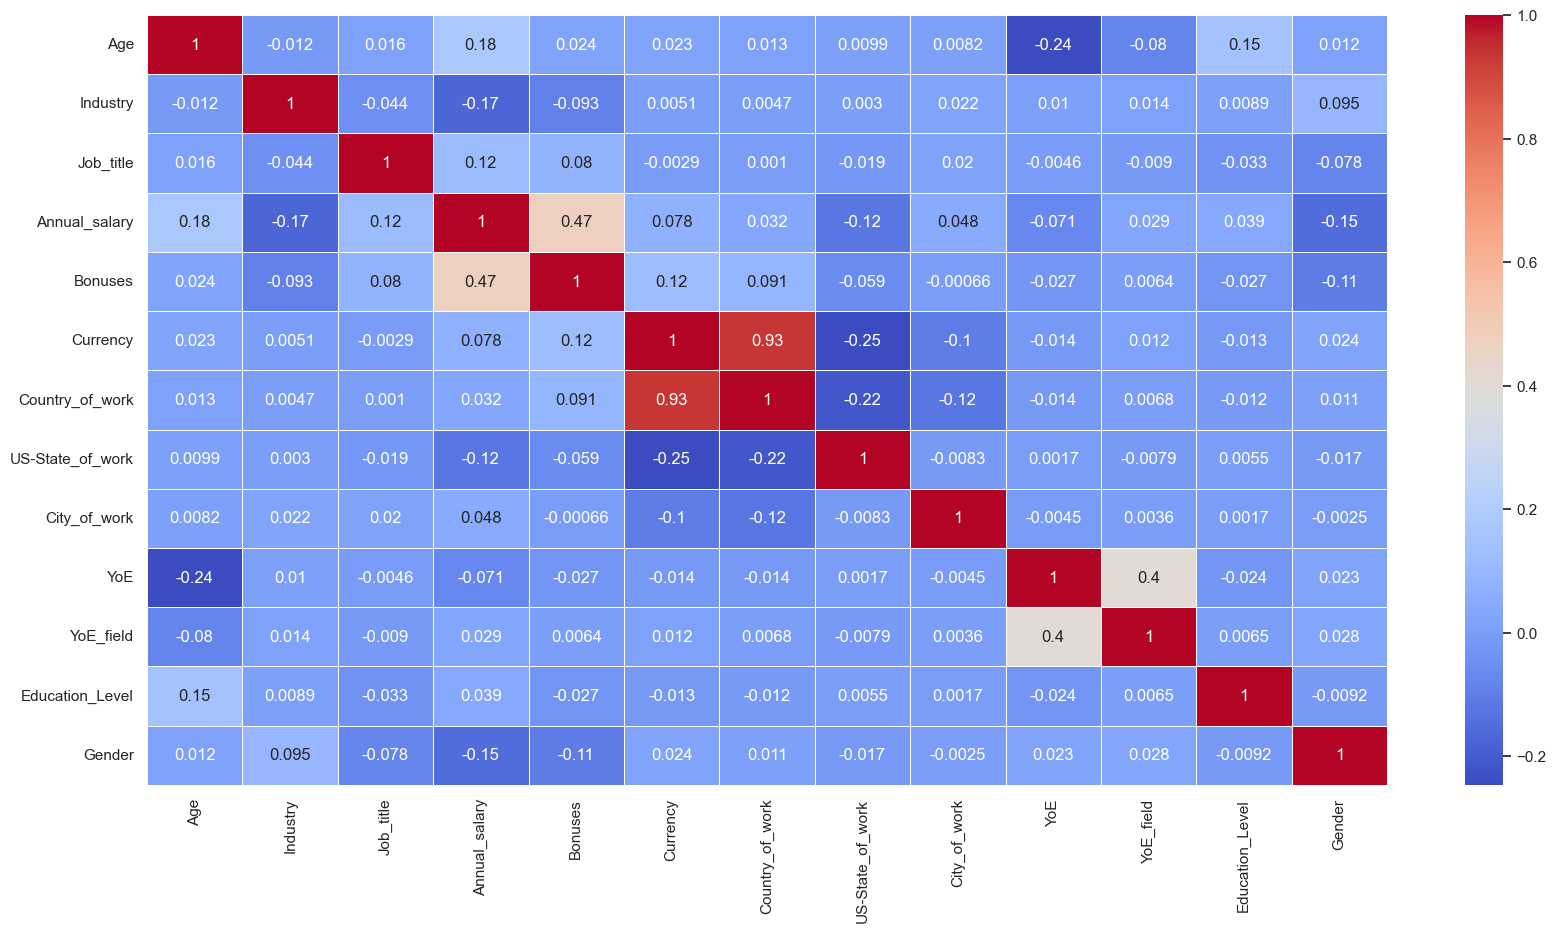

In [ ]:
corr = df_cor.corr() # Getting the correlation between all the columns
plt.figure(figsize=(20,10)) # Figure size
sns.heatmap(data=corr, cmap="coolwarm", linewidths=0.5, annot=True) # Heat map
plt.show()

### Feature selection

In [ ]:
columns = df_cor.columns
columns

Index(['Age', 'Industry', 'Job_title', 'Annual_salary', 'Bonuses', 'Currency',
       'Country_of_work', 'US-State_of_work', 'City_of_work', 'YoE',
       'YoE_field', 'Education_Level', 'Gender'],
      dtype='object')

In [ ]:
df_cor = df_cor[['Age', 'Industry', 'Job_title', 'Bonuses', 'Currency','Country_of_work', 'US-State_of_work',
     'City_of_work', 'YoE','YoE_field', 'Education_Level', 'Gender','Annual_salary']]

In [ ]:
x = df_cor.iloc[:,0:12] # Independent columns
y = df_cor.iloc[:,-1] # Target columns

# Applying selectkbest to get the best 5 columns
bestfeatures = SelectKBest(score_func=chi2, k=5)
fit = bestfeatures.fit(x,y)
dfscores = pd.DataFrame(fit.scores_.round(2))
dfcolumns = pd.DataFrame(x.columns)

In [ ]:
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(5,'Score'))  #print 5 best features

              Specs        Score
3           Bonuses  48712981.43
2         Job_title   6725229.67
7      City_of_work   1994141.10
6  US-State_of_work     47834.77
1          Industry     30538.75


In [19]:
df

,Age,Industry,Job_title,Annual_salary,Bonuses,Currency,Country_of_work,US-State_of_work,City_of_work,YoE,YoE_field,Education_Level,Gender
0,25-34,Education (Higher Education),Research and Instruction Librarian,"55,000",0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,25-34,Computing or Tech,Change & Internal Communications Manager,"54,600",4000.0,GBP,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary
2,25-34,"Accounting, Banking & Finance",Marketing Specialist,"34,000",NaN,USD,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman
3,25-34,Nonprofits,Program Manager,"62,000",3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
4,25-34,"Accounting, Banking & Finance",Accounting Manager,"60,000",7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27927,45-54,Education (Primary/Secondary),Curriculum Writer,70000,0.0,USD,United States,South Carolina,Bennettsville,21 - 30 years,21 - 30 years,Master's degree,Woman
27928,55-64,Government and Public Administration,Clerical Officer,28600,NaN,EUR,Ireland,NaN,Dublin,21 - 30 years,1 year or less,"Professional degree (MD, JD, etc.)",Man
27929,18-24,Computing or Tech,Software Engineering Co-Op,56160,0.0,USD,United States,Rhode Island,Jhonston,1 year or less,1 year or less,College degree,Man
27930,65 or over,Social networks,Content creator,2000000,NaN,USD,Taiwan,"Utah, Wisconsin",Milwaukee,41 years or more,2 - 4 years,PhD,Non-binary
